<h3> SciPython/Practical_classes_4

Exercise1: One built a model for predicting the category of a binary variable $Y$ based on features $X_1$ and $X_2$.
    
$p = \frac{1}{1+e^{-2X_1+4X_2+1}}$
   
To which category do the following observations belong according to the model?

Observations:

1. $X_1=3$, $X_2=1$
2. $X_1=2$, $X_2=1$
3. $X_1=2$, $X_2=2$
    
    
If the true labels are: 1, 0, and 0, what is the value of the Binary Cross-Entropy (BCE)?


$\text{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$


In [1]:
import numpy as np
x = np.array([[3,1], [2,1], [2,2]])
y = np.array([1,0,0])

def sigmoid(z): #sigmoid function
    sig = 1 / (1 + np.exp(-z))
    return sig

def fun_z(x1, x2): # z
    z = 2*x1 - 4*x2 - 1
    return z

z_val = np.array([fun_z(x1, x2) for x1, x2 in x]) #calculate z for each pair
probs = sigmoid(z_val) #calculate sigmoid for each z

print(f"Probailities: {probs}")

pred_cat = (probs > .5).astype(int)   #categorise
print(f"Category prediction: {pred_cat}")

def bce(probs, y):
    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps) #avoid log 0; p=0 -> p = esp; p=1 -> p=1-eps
    return -1/ len(probs) * sum(y[i] * np.log(probs[i]) + (1-y[i]) * np.log(1-probs[i]) for i in range(len(probs)))
print(f"BCE = {bce(probs, y): .4f}")

Probailities: [0.73105858 0.26894142 0.00669285]
Category prediction: [1 0 0]
BCE =  0.2111


<h4> Exercise2: Consider Breast Cancer Dataset

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = data.data
y = data.target

<h4> The goal is to predict whether a tumor is malignant or benign based on various medical features using a logistic regression model.

- What is the number of samples?

- Split the dataset into training and test sets (8:2).

- Train the model on the training data.
    
- Which features have a positive/negative impact on malignancy?

- Calculate accuracy on both the training and test sets.

In [3]:
len(data.target)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, train_size=0.8, random_state=42)

from sklearn import linear_model
model = linear_model.LogisticRegression(multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)
print(f'Accuracy:')
print(model.score(X_train, y_train))

Accuracy:
0.9428571428571428


c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
import pandas as pd
coef_df = pd.DataFrame({
    "Feature": data.feature_names,
    "coef": model.coef_[0]
})

coef_df = coef_df.sort_values(by='coef', ascending=False)
print(coef_df) 

#Interptering results:
#big coef -> malignant pred
#small coef -> benign pred
#oef 0 -> neutral pred

                    Feature      coef
20             worst radius  0.711744
0               mean radius  0.677859
11            texture error  0.300407
1              mean texture  0.264712
2            mean perimeter  0.046032
12          perimeter error  0.028781
10             radius error  0.023378
19  fractal dimension error -0.002223
14         smoothness error -0.002441
3                 mean area -0.004663
9    mean fractal dimension -0.007929
23               worst area -0.008740
18           symmetry error -0.009194
17     concave points error -0.009456
15        compactness error -0.025321
4           mean smoothness -0.026152
29  worst fractal dimension -0.034961
16          concavity error -0.035033
8             mean symmetry -0.039053
24         worst smoothness -0.046495
13               area error -0.047564
7       mean concave points -0.073590
22          worst perimeter -0.109079
5          mean compactness -0.124305
28           worst symmetry -0.125804
27     worst

<h4> Exercise3: Justify the above probabilities based on the model parameters through direct calculations.

In [6]:
from sklearn import linear_model

model = linear_model.LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.1) #C = 1/beta  (regularization L2)

X = np.array([[1,2],[2,3],[4,5],[1,-4],[5,-7],[-3,-1]])
y  = np.array([0, 0, 0, 1, 1, 2])

model.fit(X,y);

print(model.coef_, model.intercept_)
print(model.predict_proba([[-3,-1]]))

x2 = np.array([-3,-1])

param = model.coef_
formula = np.exp(np.dot(x2, param.T) + model.intercept_) / np.sum(np.exp(np.dot(x2, param.T) + model.intercept_))

print(formula)

[[ 0.12037912  0.26801754]
 [ 0.1071684  -0.25051587]
 [-0.22754753 -0.01750167]] [ 0.48071349 -0.27245434 -0.20825915]
[[0.26882204 0.22119559 0.50998236]]
[0.26882204 0.22119559 0.50998236]


c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<h4> Exercise4: Consider Wine Dataset

In [7]:
from sklearn.datasets import load_wine

data = load_wine()

X = data.data
y = data.target

<h4> The goal is to classify wines into one of three classes (types) based on their features.

- Split the dataset into training, test, and validation sets (with a ratio of 6:2:2).

- Train the model using the training data. Experiment with different values for the regularization parameter $C$ (e.g., 0.001, 0.01, 0.1, 1, 10, 100). Calculate the accuracy on the validation set.

- Finally, calculate the accuracy on the test set using the chosen/optimal $C$ parameter

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, train_size=0.6, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=42)

In [9]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

C = [0.001, 0.01, 0.1, 1, 10, 100]
for val in C:
    model = linear_model.LogisticRegression(C = val)
    model.fit(X_train, y_train) #fitujemy na zbiorze treningowym
    y_pred = model.predict(X_validation) #predykcja x na zbiorze validacyjnym

    print(val)
    r_sq = model.score(X_validation, y_validation) 
    print(r_sq)  

    mse = mean_squared_error(y_validation, y_pred)
    print(mse)

#najlepszy parametr to 100

0.001
0.75
0.3333333333333333
0.01
0.9166666666666666
0.08333333333333333
0.1
0.9444444444444444
0.05555555555555555
1
0.9444444444444444
0.05555555555555555
10
0.9444444444444444
0.05555555555555555
100
0.9722222222222222
0.027777777777777776


c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.

In [10]:
model = linear_model.LogisticRegression(C = 100)
model.fit(X_train, y_train) #fitujemy na zbiorze treningowym

r_sq = model.score(X_test, y_test) 
print(r_sq)  

mse = mean_squared_error(y_test, model.predict(X_test))
print(mse)

0.9166666666666666
0.08333333333333333


c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Exercise5: Open the "logistic_regression" file, which contains information about the actual classes and predictions according to the logistic regression model for subsequent observations.

- Calculate the values of $S_n$ (sensitivity) and $S_p$ (specificity) for 20 equally spaced $p_c$ values ranging from 0 to 1.

- Plot the ROC curve and mark the point corresponding to $p_c = 0.5$.

- Calculate the Area Under the Curve (AUC).

Sensitivity: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9541984732824428, 0.8797709923664122, 0.7958015267175572, 0.7194656488549618, 0.6259541984732825, 0.5534351145038168, 0.45038167938931295, 0.35877862595419846, 0.2595419847328244, 0.1717557251908397, 0.07824427480916031, 0.0]
Specificity: [0.0, 0.06512605042016807, 0.15126050420168066, 0.25210084033613445, 0.3403361344537815, 0.42016806722689076, 0.5189075630252101, 0.615546218487395, 0.726890756302521, 0.8130252100840336, 0.8886554621848739, 0.9684873949579832, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


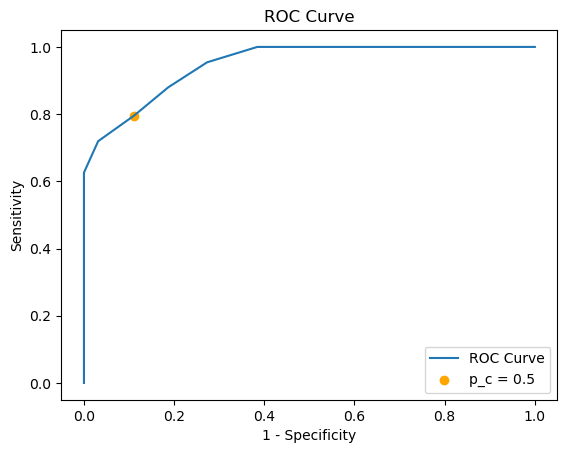

Area: 0.9483690422733979


C:\Users\kajaw\AppData\Local\Temp\ipykernel_2220\2000415871.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f'Area: {np.trapz(Sn, np.array(Sp)-1)}') #traps wymaga rosnących x wiec mieżymy pole pod lustrzanym odbicem wykresu


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('logistic_regression')

thre = np.linspace(0, 1, 20)

Sp = []
Sn = []
for tr in thre:

    df['T/F'] = (df['Predicted_p'] > tr).astype(int)

    TP = df[(df['Class'] == 1) & (df['T/F'] == 1)].shape[0]
    TN = df[(df['Class'] == 0) & (df['T/F'] == 0)].shape[0]
    FP = df[(df['Class'] == 0) & (df['T/F'] == 1)].shape[0]
    FN = df[(df['Class'] == 1) & (df['T/F'] == 0)].shape[0]

    Sn.append(TP / (TP +FN))
    Sp.append(TN / (TN + FP))

print(f'Sensitivity: {Sn}')
print(f'Specificity: {Sp}')

plt.plot(1 - np.array(Sp), Sn, label='ROC Curve')
plt.scatter(1 - Sp[10], Sn[10], color='orange', label='p_c = 0.5')

plt.title('ROC Curve')
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.legend()
plt.show()

#auc
import numpy as np 
print(f'Area: {np.trapz(Sn, np.array(Sp)-1)}')
#traps wymaga rosnących x wiec mieżymy pole pod odbicem wykresu (wzdłuz osi x)